# **Machine Learning Assignment :- 13**


**   **
**Name: Ghrushnesh Sudhakar Patil**

**Class: CSAI-D**     

**Batch : 3**

**Roll No: 66**

**PRN: 12411658**



---






**Q. Implement K-Means clustering on Iris.csv dataset. Determine the number of clusters using the elbow method.**

 **DATASET LINK :- https://www.kaggle.com/datasets/uciml/iris**


---



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Dataset

In [ ]:
iris = load_iris()
dataset = pd.DataFrame(data=iris.data, columns=iris.feature_names)
dataset.head()
dataset.info()
dataset.describe()
dataset.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


#Data Scatter Plot

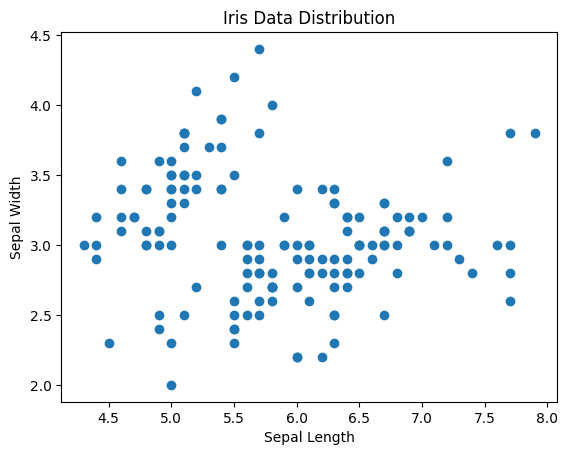

In [ ]:
plt.scatter(dataset.iloc[:, 0], dataset.iloc[:, 1])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Data Distribution")
plt.show()

#Elbow Method


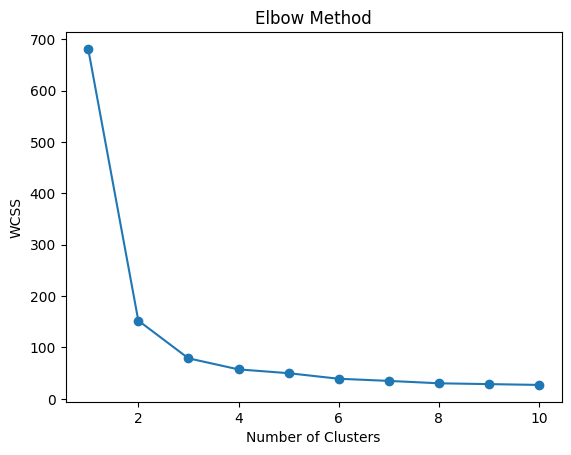

In [ ]:
X = dataset.values
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=17)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

#Silhouette Score

K = 2, Silhouette Score = 0.6810
K = 3, Silhouette Score = 0.5512
K = 4, Silhouette Score = 0.4976
K = 5, Silhouette Score = 0.4931
K = 6, Silhouette Score = 0.3678
K = 7, Silhouette Score = 0.3543
K = 8, Silhouette Score = 0.3447
K = 9, Silhouette Score = 0.3156
K = 10, Silhouette Score = 0.3014


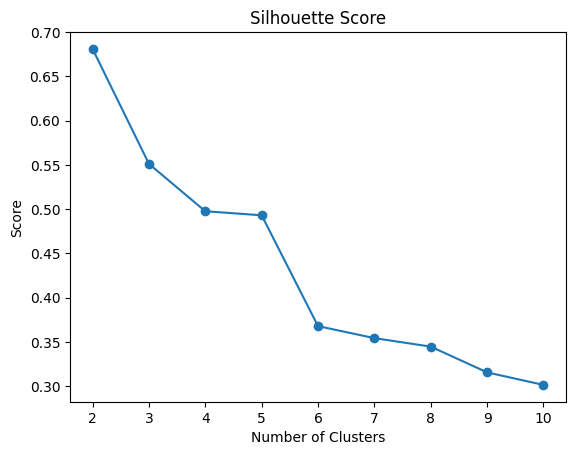

In [ ]:
sil_scores = []
for i in range(2,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  labels = kmeans.fit_predict(X)
  score = silhouette_score(X, labels)
  sil_scores.append(score)
  print(f"K = {i}, Silhouette Score = {score:.4f}")

plt.plot(range(2,11), sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

#Clustering

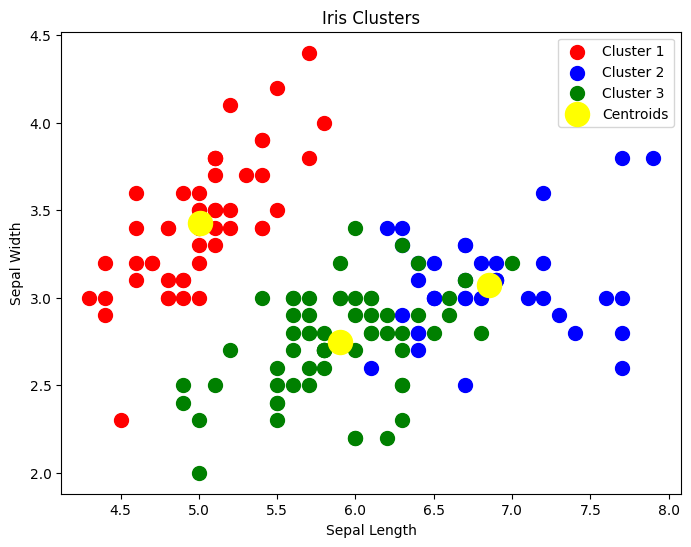

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=12)
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
s=300, c='yellow', label='Centroids')
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Clusters")
plt.legend()
plt.show()